In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import altair as alt
alt.data_transformers.disable_max_rows()

DataTransformerRegistry.enable('default')

In [41]:
# route = pd.read_csv('Aqueduct40_waterrisk_download_Y2023M07D05/CVS/Aqueduct40_baseline_annual_y2023m07d05.csv')
url = "https://github.com/wolfzbp/Global-Water-Indicators-based-on-Aqueduct-4.0/releases/download/v1.0/Aqueduct40_baseline_annual_y2023m07d05.csv"
route = pd.read_csv(url)

In [42]:
df=pd.DataFrame(route)
df

,string_id,aq30_id,pfaf_id,gid_1,aqid,gid_0,name_0,name_1,area_km2,bws_raw,...,w_awr_tex_qal_label,w_awr_tex_rrr_raw,w_awr_tex_rrr_score,w_awr_tex_rrr_cat,w_awr_tex_rrr_label,w_awr_tex_tot_raw,w_awr_tex_tot_score,w_awr_tex_tot_cat,w_awr_tex_tot_label,w_awr_tex_tot_weight_fraction
0,111011-EGY.11_1-3365,0,111011,EGY.11_1,3365,EGY,Egypt,Al Qahirah,4.223754,9999.0,...,Low - Medium (1-2),1.622678,2.163858,2.0,Medium - High (2-3),2.509062,3.705279,3.0,High (3-4),0.877551
1,111011-EGY.15_1-3365,1,111011,EGY.15_1,3365,EGY,Egypt,As Suways,1846.012343,9999.0,...,Low - Medium (1-2),1.622678,2.163858,2.0,Medium - High (2-3),2.509062,3.705279,3.0,High (3-4),0.877551
2,111011-EGY.15_1-None,2,111011,EGY.15_1,-9999,EGY,Egypt,As Suways,30.526067,9999.0,...,Low - Medium (1-2),1.622678,2.163858,2.0,Medium - High (2-3),2.509062,3.705279,3.0,High (3-4),0.877551
3,111011-None-3365,3,111011,-9999,3365,NaN,NaN,NaN,0.742712,9999.0,...,No data,-9999.000000,-9999.000000,-9999.0,No data,-9999.000000,-9999.000000,-9999.0,No data,0.551020
4,111011-None-None,4,111011,-9999,-9999,NaN,NaN,NaN,13.430995,9999.0,...,No data,-9999.000000,-9999.000000,-9999.0,No data,-9999.000000,-9999.000000,-9999.0,No data,0.551020
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68505,None-YEM.5_1-None,68506,-9999,YEM.5_1,-9999,YEM,Yemen,Al Hudaydah,0.887022,-9999.0,...,No data,-9999.000000,-9999.000000,-9999.0,No data,-9999.000000,-9999.000000,-9999.0,No data,0.326531
68506,None-ZAF.1_1-None,68507,-9999,ZAF.1_1,-9999,ZAF,South Africa,Eastern Cape,0.019523,-9999.0,...,No data,-9999.000000,-9999.000000,-9999.0,No data,-9999.000000,-9999.000000,-9999.0,No data,0.326531
68507,None-ZAF.4_1-None,68508,-9999,ZAF.4_1,-9999,ZAF,South Africa,KwaZulu-Natal,0.085616,-9999.0,...,No data,-9999.000000,-9999.000000,-9999.0,No data,-9999.000000,-9999.000000,-9999.0,No data,0.326531
68508,None-ZAF.9_1-2940,68509,-9999,ZAF.9_1,2940,ZAF,South Africa,Western Cape,0.015411,-9999.0,...,No data,-9999.000000,-9999.000000,-9999.0,No data,-9999.000000,-9999.000000,-9999.0,No data,0.326531


In [43]:
countries = df['name_0'].unique()
countries


array(['Egypt', nan, 'Sudan', 'Eritrea', 'Somalia', 'Ethiopia',
       'Djibouti', 'Yemen', 'Kenya', 'Tanzania', 'Uganda', 'South Sudan',
       'Zambia', 'Mozambique', 'Malawi', 'Zimbabwe',
       'Democratic Republic of the Congo', 'Botswana', 'Namibia',
       'Angola', 'South Africa', 'Swaziland', 'Lesotho',
       'Republic of Congo', 'Gabon', 'Central African Republic',
       'Cameroon', 'Burundi', 'Rwanda', 'Equatorial Guinea', 'Nigeria',
       'São Tomé and Príncipe', 'Chad', 'Benin', 'Niger', 'Mali',
       'Algeria', 'Burkina Faso', 'Mauritania', "Côte d'Ivoire", 'Guinea',
       'Sierra Leone', 'Togo', 'Ghana', 'Liberia', 'Guinea-Bissau',
       'Senegal', 'Gambia', 'Western Sahara', 'Morocco', 'Spain',
       'Portugal', 'Tunisia', 'Italy', 'Libya', 'Madagascar',
       'French Southern Territories', 'Comoros', 'Mayotte', 'Seychelles',
       'Israel', 'Palestina', 'Lebanon', 'Syria', 'Turkey', 'Cyprus',
       'Akrotiri and Dhekelia', 'Northern Cyprus', 'Greece', 'Bulgar

In [48]:
africa = [
    'Egypt','Sudan','Eritrea','Somalia','Ethiopia','Djibouti',
    'Kenya','Tanzania','Uganda','South Sudan','Zambia','Mozambique',
    'Malawi','Zimbabwe','Democratic Republic of the Congo','Botswana',
    'Namibia','Angola','South Africa','Swaziland','Lesotho',
    'Republic of Congo','Gabon','Central African Republic','Cameroon',
    'Burundi','Rwanda','Equatorial Guinea','Nigeria',
    'São Tomé and Príncipe','Chad','Benin','Niger','Mali',
    'Algeria','Burkina Faso','Mauritania',"Côte d'Ivoire",
    'Guinea','Sierra Leone','Togo','Ghana','Liberia','Guinea-Bissau',
    'Senegal','Gambia','Western Sahara','Morocco','Tunisia','Libya',
    'Madagascar','Comoros','Seychelles','Cape Verde','Mauritius',
    'Reunion','Mayotte','Saint Helena','French Southern Territories'
]

europe = [
    'Spain','Portugal','Italy','Greece','Bulgaria','Macedonia',
    'Serbia','Kosovo','Albania','Montenegro',
    'Bosnia and Herzegovina','Croatia','Slovenia','Austria',
    'Switzerland','France','San Marino','Andorra','Malta',
    'Germany','Belgium','Netherlands','Luxembourg','Liechtenstein',
    'United Kingdom','Ireland','Denmark','Lithuania','Latvia',
    'Estonia','Finland','Norway','Sweden','Iceland','Poland',
    'Romania','Hungary','Slovakia','Czech Republic','Ukraine',
    'Belarus','Moldova','Russia','Georgia',
    'Guernsey','Jersey','Isle of Man','Faroe Islands','Åland',
    'Svalbard and Jan Mayen'
]

asia = [
    'Yemen','Israel','Palestina','Lebanon','Syria','Turkey','Cyprus',
    'Iran','Afghanistan','Iraq','Azerbaijan','Armenia','Pakistan',
    'Saudi Arabia','Jordan','Kuwait','Bahrain','Qatar',
    'United Arab Emirates','Oman','China','Mongolia','Japan',
    'North Korea','South Korea','Taiwan','Hong Kong','Macao',
    'Vietnam','Laos','Cambodia','Thailand','Myanmar','Malaysia',
    'Singapore','India','Bangladesh','Nepal','Bhutan','Sri Lanka',
    'Tajikistan','Kyrgyzstan','Indonesia','Timor-Leste','Brunei',
    'Philippines','Kazakhstan','Uzbekistan','Turkmenistan',
    'Akrotiri and Dhekelia','Northern Cyprus'
]

north_america = [
    'United States','Canada','Mexico','Greenland',
    'Bermuda','Saint Pierre and Miquelon'
]

central_america = [
    'Guatemala','Belize','Honduras','Nicaragua',
    'Costa Rica','Panama','El Salvador'
]

caribbean = [
    'Bahamas','Cuba','Jamaica','Haiti','Dominican Republic',
    'Barbados','Trinidad and Tobago','Puerto Rico',
    'Bonaire, Sint Eustatius and Saba','Grenada','Saint Lucia',
    'Martinique','Saint Vincent and the Grenadines',
    'Turks and Caicos Islands','Cayman Islands',
    'Antigua and Barbuda','Dominica','Guadeloupe',
    'Saint Kitts and Nevis','Montserrat',
    'British Virgin Islands','Virgin Islands, U.S.'
]

south_america = [
    'Colombia','Venezuela','Brazil','Guyana','Suriname',
    'French Guiana','Bolivia','Peru','Ecuador','Uruguay',
    'Argentina','Paraguay','Chile'
]

oceania = [
    'Australia','New Zealand','Papua New Guinea','Fiji',
    'Solomon Islands','Vanuatu','Samoa','Tonga','Tuvalu',
    'Micronesia','Palau','Nauru','New Caledonia',
    'French Polynesia','Wallis and Futuna','Tokelau',
    'Guam','Northern Mariana Islands',
    'United States Minor Outlying Islands','American Samoa'
]
continent_map = {}

for c in africa:
    continent_map[c] = 'Africa'

for c in europe:
    continent_map[c] = 'Europe'

for c in asia:
    continent_map[c] = 'Asia'

for c in north_america:
    continent_map[c] = 'North America'
for c in central_america:
    continent_map[c] = 'Central America'
for c in caribbean:
    continent_map[c] = 'Caribbean'
for c in south_america:
    continent_map[c] = 'South America'

for c in oceania:
    continent_map[c] = 'Oceania'

df['continent'] = df['name_0'].map(continent_map)
df.groupby('continent')['name_0'].count()

continent
Africa             13231
Asia               14833
Caribbean            686
Central America      765
Europe             10688
North America       8738
Oceania             2830
South America       6717
Name: name_0, dtype: int64

In [49]:
df[df['continent'].isna()]['name_0'].unique()

array([nan], dtype=object)

In [50]:
# eliminar valores que tienen -9999 en bws_score
df = df[df['bws_score'] != -9999]

In [51]:
avg_country = df.groupby('name_0')['bws_score'].mean().reset_index()
# mapear continentes
avg_country['continent'] = avg_country['name_0'].map(continent_map)
avg_country[avg_country['continent'].isna()]

,name_0,bws_score,continent


In [52]:
avg_country.dropna(inplace=True)
avg_country.sort_values(by='bws_score',inplace=True)

In [56]:
# altair graficar estres hidrico por pais, colorear por continente, promediar por name_0
alt.Chart(
    avg_country[avg_country['bws_score'] > 0]
    .sort_values(by='bws_score', ascending=False)
    .head(80)
).mark_bar().encode(
    x=alt.X('name_0:N', sort='-y'),
    y=alt.Y('bws_score:Q', title='Average BWS Score'),
    color=alt.Color('continent:N')
).properties(
    width=800,
    height=400
).configure_axisX(
    labelAngle=-90
)

alt.Chart(...)

In [9]:
df.groupby('name_0')['name_0'].count()

name_0
Afghanistan              401
Akrotiri and Dhekelia      3
Albania                   59
Algeria                  842
American Samoa             6
                        ... 
Western Sahara            84
Yemen                    219
Zambia                   299
Zimbabwe                 180
Åland                     55
Name: name_0, Length: 228, dtype: int64

In [28]:
print(df.columns, flush=False)

Index(['string_id', 'aq30_id', 'pfaf_id', 'gid_1', 'aqid', 'gid_0', 'name_0',
       'name_1', 'area_km2', 'bws_raw',
       ...
       'w_awr_tex_qal_label', 'w_awr_tex_rrr_raw', 'w_awr_tex_rrr_score',
       'w_awr_tex_rrr_cat', 'w_awr_tex_rrr_label', 'w_awr_tex_tot_raw',
       'w_awr_tex_tot_score', 'w_awr_tex_tot_cat', 'w_awr_tex_tot_label',
       'w_awr_tex_tot_weight_fraction'],
      dtype='object', length=231)


In [29]:
df_ecuador = df.query('name_0=="Ecuador"')

In [30]:
# df_ecuador.drop(columns=['string_id',], inplace=True)

In [31]:
# guardar el nuevo dataframe en un nuevo archivo csv
df_ecuador.to_csv('Aqueduct40_waterrisk_download_Y2023M07D05/CVS/Aqueduct40_ecuador_annual_y2023m07d05.csv', index=False)
if __name__ == "__main__":
    print("Archivo procesado y guardado exitosamente.")

Archivo procesado y guardado exitosamente.


In [32]:
df.describe()

,aq30_id,pfaf_id,aqid,area_km2,bws_raw,bws_score,bws_cat,bwd_raw,bwd_score,bwd_cat,...,w_awr_tex_qal_raw,w_awr_tex_qal_score,w_awr_tex_qal_cat,w_awr_tex_rrr_raw,w_awr_tex_rrr_score,w_awr_tex_rrr_cat,w_awr_tex_tot_raw,w_awr_tex_tot_score,w_awr_tex_tot_cat,w_awr_tex_tot_weight_fraction
count,68510.000000,68510.000000,68510.000000,6.851000e+04,68510.000000,68510.000000,68510.000000,68510.000000,68510.000000,68510.000000,...,68510.000000,68510.000000,68510.000000,68510.000000,68510.000000,68510.000000,68510.000000,68510.000000,68510.000000,68510.000000
mean,34253.930025,397997.499226,574.553569,2.164186e+03,-829.201019,-1022.802698,-1023.698278,-829.338387,-1022.998833,-1023.903795,...,-2102.494985,-2102.541087,-2102.937615,-2102.846451,-2102.581044,-2102.991111,-2103.071559,-2102.492304,-2102.841483,0.818866
std,19776.976893,253318.363063,3836.661352,4.650572e+04,3391.323913,3032.445621,3032.142763,3391.290182,3032.379272,3032.073232,...,4077.381185,4077.357423,4077.152697,4077.199739,4077.336725,4077.124989,4077.083383,4077.382567,4077.202303,0.228548
min,0.000000,-9999.000000,-9999.000000,2.826032e-03,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,...,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,0.000000
25%,17128.250000,172198.250000,857.000000,3.194914e+01,0.000189,0.000000,0.000000,0.000096,0.001929,0.000000,...,0.877014,0.604837,0.000000,0.280000,0.933333,0.000000,0.554951,0.549456,0.000000,0.877551
50%,34251.500000,361011.500000,1644.000000,3.675729e+02,0.023303,0.000000,0.000000,0.008844,0.176877,0.000000,...,2.419656,2.305078,2.000000,1.833333,2.312207,2.000000,1.909980,2.612204,2.000000,0.918367
75%,51380.750000,622692.000000,2531.000000,2.220049e+03,0.430702,3.106691,1.000000,0.181831,1.659157,0.000000,...,3.537968,3.679086,3.000000,3.309959,3.446392,3.000000,2.632423,3.917970,3.000000,0.918367
max,68510.000000,914900.000000,3401.000000,1.212893e+07,9999.000000,5.000000,4.000000,9999.000000,5.000000,4.000000,...,5.000000,5.000000,4.000000,5.000000,5.000000,4.000000,4.618412,4.835523,4.000000,1.755102


In [33]:
# imprimir todos los nombres de las columnas
for i in df.columns:
    print(i)

string_id
aq30_id
pfaf_id
gid_1
aqid
gid_0
name_0
name_1
area_km2
bws_raw
bws_score
bws_cat
bws_label
bwd_raw
bwd_score
bwd_cat
bwd_label
iav_raw
iav_score
iav_cat
iav_label
sev_raw
sev_score
sev_cat
sev_label
gtd_raw
gtd_score
gtd_cat
gtd_label
rfr_raw
rfr_score
rfr_cat
rfr_label
cfr_raw
cfr_score
cfr_cat
cfr_label
drr_raw
drr_score
drr_cat
drr_label
ucw_raw
ucw_score
ucw_cat
ucw_label
cep_raw
cep_score
cep_cat
cep_label
udw_raw
udw_score
udw_cat
udw_label
usa_raw
usa_score
usa_cat
usa_label
rri_raw
rri_score
rri_cat
rri_label
w_awr_def_qan_raw
w_awr_def_qan_score
w_awr_def_qan_cat
w_awr_def_qan_label
w_awr_def_qal_raw
w_awr_def_qal_score
w_awr_def_qal_cat
w_awr_def_qal_label
w_awr_def_rrr_raw
w_awr_def_rrr_score
w_awr_def_rrr_cat
w_awr_def_rrr_label
w_awr_def_tot_raw
w_awr_def_tot_score
w_awr_def_tot_cat
w_awr_def_tot_label
w_awr_def_tot_weight_fraction
w_awr_agr_qan_raw
w_awr_agr_qan_score
w_awr_agr_qan_cat
w_awr_agr_qan_label
w_awr_agr_qal_raw
w_awr_agr_qal_score
w_awr_agr_qal_cat


In [34]:
# seleccionar todas las columnas que tengan la palabra "score" en su nombre

score_columns = []
score_columns.append('string_id')
score_columns.append('aq30_id')
score_columns.append('pfaf_id')
score_columns.append('gid_1')
score_columns.append('aqid')
score_columns.append('gid_0')
score_columns.append('name_0')
score_columns.append('name_1')
score_columns.append('area_km2')
scores_list = [col for col in df_ecuador.columns if 'score' in col]
score_columns.extend(scores_list)
# extraer solo esas columnas
df_scores = df_ecuador[score_columns]
df_scores

,string_id,aq30_id,pfaf_id,gid_1,aqid,gid_0,name_0,name_1,area_km2,bws_score,...,w_awr_ong_rrr_score,w_awr_ong_tot_score,w_awr_smc_qan_score,w_awr_smc_qal_score,w_awr_smc_rrr_score,w_awr_smc_tot_score,w_awr_tex_qan_score,w_awr_tex_qal_score,w_awr_tex_rrr_score,w_awr_tex_tot_score
46547,622974-ECU.22_1-2150,46546,622974,ECU.22_1,2150,ECU,Ecuador,Sucumbios,4859.409663,0.0,...,3.87859,3.562376,0.707724,2.839580,3.850163,2.630695,0.634583,3.275359,3.850163,3.233018
46548,622974-ECU.22_1-2276,46547,622974,ECU.22_1,2276,ECU,Ecuador,Sucumbios,631.162587,0.0,...,3.87859,3.562376,0.707724,2.839580,3.850163,2.630695,0.634583,3.275359,3.850163,3.233018
46549,622974-ECU.22_1-2339,46548,622974,ECU.22_1,2339,ECU,Ecuador,Sucumbios,9.114946,0.0,...,3.87859,3.562376,0.707724,2.839580,3.850163,2.630695,0.634583,3.275359,3.850163,3.233018
46563,622978-ECU.11_1-2339,46562,622978,ECU.11_1,2339,ECU,Ecuador,Imbabura,2.633220,0.0,...,3.69301,3.439725,0.935432,2.839388,3.710978,2.722120,0.843105,3.275268,3.710978,3.246718
46564,622978-ECU.16_1-2150,46563,622978,ECU.16_1,2150,ECU,Ecuador,Napo,1511.822802,0.0,...,3.69301,3.439725,0.935432,2.839388,3.710978,2.722120,0.843105,3.275268,3.710978,3.246718
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
64048,None-ECU.8_1-2200,64048,-9999,ECU.8_1,2200,ECU,Ecuador,Esmeraldas,5.563992,-9999.0,...,-9999.00000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000
64049,None-ECU.8_1-2340,64049,-9999,ECU.8_1,2340,ECU,Ecuador,Esmeraldas,15.137668,-9999.0,...,-9999.00000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000
64050,None-ECU.8_1-None,64050,-9999,ECU.8_1,-9999,ECU,Ecuador,Esmeraldas,41.547172,-9999.0,...,-9999.00000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000
64051,None-ECU.9_1-2371,64051,-9999,ECU.9_1,2371,ECU,Ecuador,Galápagos,0.037817,-9999.0,...,-9999.00000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000


In [35]:
score_columns

['string_id',
 'aq30_id',
 'pfaf_id',
 'gid_1',
 'aqid',
 'gid_0',
 'name_0',
 'name_1',
 'area_km2',
 'bws_score',
 'bwd_score',
 'iav_score',
 'sev_score',
 'gtd_score',
 'rfr_score',
 'cfr_score',
 'drr_score',
 'ucw_score',
 'cep_score',
 'udw_score',
 'usa_score',
 'rri_score',
 'w_awr_def_qan_score',
 'w_awr_def_qal_score',
 'w_awr_def_rrr_score',
 'w_awr_def_tot_score',
 'w_awr_agr_qan_score',
 'w_awr_agr_qal_score',
 'w_awr_agr_rrr_score',
 'w_awr_agr_tot_score',
 'w_awr_che_qan_score',
 'w_awr_che_qal_score',
 'w_awr_che_rrr_score',
 'w_awr_che_tot_score',
 'w_awr_con_qan_score',
 'w_awr_con_qal_score',
 'w_awr_con_rrr_score',
 'w_awr_con_tot_score',
 'w_awr_elp_qan_score',
 'w_awr_elp_qal_score',
 'w_awr_elp_rrr_score',
 'w_awr_elp_tot_score',
 'w_awr_fnb_qan_score',
 'w_awr_fnb_qal_score',
 'w_awr_fnb_rrr_score',
 'w_awr_fnb_tot_score',
 'w_awr_min_qan_score',
 'w_awr_min_qal_score',
 'w_awr_min_rrr_score',
 'w_awr_min_tot_score',
 'w_awr_ong_qan_score',
 'w_awr_ong_qal_scor

In [36]:
# listas de columnas para cada tipo de score
identificadores = [
    "pfaf_id",
    "gid_0",
    "name_0",
    "name_1",
    "area_km2"
]

riesgo_hidrologico = [
    "bws_score",   # Baseline water stress es el score de estrés hídrico de referencia
    "bwd_score",   # Water depletion es el score de agotamiento del agua
    "iav_score",   # Interannual variability es el score de variabilidad interanual
    "sev_score",   # Seasonal variability es el score de variabilidad estacional
    "drr_score"    # Drought risk es el score de riesgo de sequía
]

eventos_hidrologicos = [
    # "gtd_score",   # Groundwater table decline es el score de riesgo de declive de la tabla de agua subterránea, pero no se encuentra en el dataset
    "rfr_score",   # River flood risk es el score de riesgo de inundación fluvial
    "cfr_score"    # Coastal flood risk es el score de riesgo de inundación costera
]

calidad_agua = [
    "ucw_score",   # Untreated wastewater es el score de aguas residuales sin tratar
    "cep_score",   # Coastal eutrophication es el score de eutrofización costera
    "udw_score",   # No drinking water es el score de ausencia de agua potable
    "usa_score"    # No sanitation es el score de ausencia de saneamiento
]

por_industria = [
    "w_awr_agr_tot_score",   # Agriculture es el score de agricultura
    "w_awr_che_tot_score",   # Chemicals es el score de productos químicos
    "w_awr_con_tot_score",   # Construction materials es el score de materiales de construcción
    "w_awr_elp_tot_score",   # Electric power es el score de energía eléctrica
    "w_awr_fnb_tot_score",   # Food & beverage es el score de alimentos y bebidas
    "w_awr_min_tot_score",   # Mining es el score de minería
    "w_awr_ong_tot_score",   # Oil & gas es el score de petróleo y gas
    "w_awr_smc_tot_score",   # Semiconductor es el score de semiconductor
    "w_awr_tex_tot_score"    # Textile es el score de textil
]

In [37]:
df_ecuador[identificadores + riesgo_hidrologico + eventos_hidrologicos + calidad_agua + por_industria].select_dtypes(include=['number']).describe()

,pfaf_id,area_km2,bws_score,bwd_score,iav_score,sev_score,drr_score,rfr_score,cfr_score,ucw_score,...,usa_score,w_awr_agr_tot_score,w_awr_che_tot_score,w_awr_con_tot_score,w_awr_elp_tot_score,w_awr_fnb_tot_score,w_awr_min_tot_score,w_awr_ong_tot_score,w_awr_smc_tot_score,w_awr_tex_tot_score
count,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,1.970000e+02,...,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000,197.000000
mean,607119.913706,1308.823020,-710.100303,-710.091577,-708.962686,-709.444821,-1064.004773,-708.198500,-709.836213,3.719695e+00,...,-707.784382,-1064.104673,-707.865404,-708.376324,-709.132888,-708.494498,-707.576571,-707.343873,-707.732460,-707.341176
std,172630.396794,2424.935686,2575.774624,2575.776999,2576.090110,2575.956237,3094.230951,2576.301950,2575.847968,4.897427e-15,...,2576.416770,3094.196355,2576.394239,2576.252563,2576.042831,2576.219794,2576.474298,2576.538814,2576.431051,2576.539534
min,-9999.000000,0.015246,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,3.719695e+00,...,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000,-9999.000000
25%,622986.000000,22.607455,0.000000,0.035473,0.634569,0.589519,1.182513,1.688855,0.000000,3.719695e+00,...,2.579009,1.356004,2.114506,1.655479,0.739504,1.662098,2.572261,3.213946,2.545538,3.097979
50%,672010.000000,295.614914,0.000000,0.096145,1.213905,1.243167,2.173825,2.314926,0.000000,3.719695e+00,...,3.158932,1.470799,2.723051,2.031235,1.227883,1.909339,3.233747,3.493064,2.819288,3.464689
75%,672029.000000,1392.741724,0.952514,0.609168,2.591930,1.825327,2.694114,3.427721,1.200119,3.719695e+00,...,3.315666,2.234117,3.588985,2.909453,2.145304,2.870607,3.844418,4.088001,3.475245,3.815150
max,673000.000000,20260.645903,5.000000,5.000000,5.000000,2.287402,3.061419,4.020639,4.005958,3.719695e+00,...,4.893261,4.039990,4.047404,4.200422,4.306943,4.366647,4.066102,4.157483,4.193192,4.129374


In [38]:
df_selected_ecuador = df_ecuador[identificadores + riesgo_hidrologico + eventos_hidrologicos + calidad_agua + por_industria]
# contar los valores -9999 por cada columna, y mostrar el porcentaje respecto al total de filas, crear un nuevo dataframe con el resultado, y mostrarlo
missing_values_count = df_selected_ecuador.isin([-9999]).sum()
total_rows = len(df_selected_ecuador)
missing_values_percentage = (missing_values_count / total_rows) * 100
df_missing_values = pd.DataFrame({'Missing Values': missing_values_count, 'Percentage': missing_values_percentage})
df_missing_values


,Missing Values,Percentage
pfaf_id,14,7.106599
gid_0,0,0.000000
name_0,0,0.000000
name_1,0,0.000000
area_km2,0,0.000000
bws_score,14,7.106599
bwd_score,14,7.106599
iav_score,14,7.106599
sev_score,14,7.106599
drr_score,21,10.659898


In [39]:
# eliminar las filas que tengan -9999 en drr
df_selected_ecuador_cleaned = df_selected_ecuador[~df_selected_ecuador['drr_score'].isin([-9999])]
df_selected_ecuador_cleaned

,pfaf_id,gid_0,name_0,name_1,area_km2,bws_score,bwd_score,iav_score,sev_score,drr_score,...,usa_score,w_awr_agr_tot_score,w_awr_che_tot_score,w_awr_con_tot_score,w_awr_elp_tot_score,w_awr_fnb_tot_score,w_awr_min_tot_score,w_awr_ong_tot_score,w_awr_smc_tot_score,w_awr_tex_tot_score
46547,622974,ECU,Ecuador,Sucumbios,4859.409663,0.0,0.000689,0.496407,0.491007,0.413270,...,4.226769,1.261114,2.501228,1.795531,0.613508,1.560531,2.896099,3.562376,2.630695,3.233018
46548,622974,ECU,Ecuador,Sucumbios,631.162587,0.0,0.000689,0.496407,0.491007,0.413270,...,4.226769,1.261114,2.501228,1.795531,0.613508,1.560531,2.896099,3.562376,2.630695,3.233018
46549,622974,ECU,Ecuador,Sucumbios,9.114946,0.0,0.000689,0.496407,0.491007,0.413270,...,4.226769,1.261114,2.501228,1.795531,0.613508,1.560531,2.896099,3.562376,2.630695,3.233018
46563,622978,ECU,Ecuador,Imbabura,2.633220,0.0,0.001753,0.585122,0.589519,1.138821,...,3.315666,1.419369,2.723051,1.900833,0.792465,1.662098,3.071448,3.439725,2.722120,3.246718
46564,622978,ECU,Ecuador,Napo,1511.822802,0.0,0.001753,0.585122,0.589519,1.138821,...,3.315666,1.419369,2.723051,1.900833,0.792465,1.662098,3.071448,3.439725,2.722120,3.246718
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51547,672050,ECU,Ecuador,Esmeraldas,1797.863787,0.0,0.035473,0.836805,0.777328,2.161671,...,3.433801,1.798227,3.596054,2.467429,1.848435,1.909339,3.844418,4.157483,3.054440,3.796180
51548,672050,ECU,Ecuador,Esmeraldas,7043.230399,0.0,0.035473,0.836805,0.777328,2.161671,...,3.433801,1.798227,3.596054,2.467429,1.848435,1.909339,3.844418,4.157483,3.054440,3.796180
51549,672050,ECU,Ecuador,Esmeraldas,289.052069,0.0,0.035473,0.836805,0.777328,2.161671,...,3.433801,1.798227,3.596054,2.467429,1.848435,1.909339,3.844418,4.157483,3.054440,3.796180
51564,672060,ECU,Ecuador,Carchi,295.614914,0.0,0.051794,0.737349,0.415765,1.794574,...,3.808909,1.336307,1.892401,1.571521,0.655057,1.614536,2.469782,3.176967,2.420294,3.045720


In [40]:
missing_values_count = df_selected_ecuador_cleaned.isin([-9999]).sum()
total_rows = len(df_selected_ecuador_cleaned)
missing_values_percentage = (missing_values_count / total_rows) * 100
df_missing_values = pd.DataFrame({'Missing Values': missing_values_count, 'Percentage': missing_values_percentage})
df_missing_values

,Missing Values,Percentage
pfaf_id,0,0.0
gid_0,0,0.0
name_0,0,0.0
name_1,0,0.0
area_km2,0,0.0
bws_score,0,0.0
bwd_score,0,0.0
iav_score,0,0.0
sev_score,0,0.0
drr_score,0,0.0


In [41]:
df_selected_ecuador_cleaned

,pfaf_id,gid_0,name_0,name_1,area_km2,bws_score,bwd_score,iav_score,sev_score,drr_score,...,usa_score,w_awr_agr_tot_score,w_awr_che_tot_score,w_awr_con_tot_score,w_awr_elp_tot_score,w_awr_fnb_tot_score,w_awr_min_tot_score,w_awr_ong_tot_score,w_awr_smc_tot_score,w_awr_tex_tot_score
46547,622974,ECU,Ecuador,Sucumbios,4859.409663,0.0,0.000689,0.496407,0.491007,0.413270,...,4.226769,1.261114,2.501228,1.795531,0.613508,1.560531,2.896099,3.562376,2.630695,3.233018
46548,622974,ECU,Ecuador,Sucumbios,631.162587,0.0,0.000689,0.496407,0.491007,0.413270,...,4.226769,1.261114,2.501228,1.795531,0.613508,1.560531,2.896099,3.562376,2.630695,3.233018
46549,622974,ECU,Ecuador,Sucumbios,9.114946,0.0,0.000689,0.496407,0.491007,0.413270,...,4.226769,1.261114,2.501228,1.795531,0.613508,1.560531,2.896099,3.562376,2.630695,3.233018
46563,622978,ECU,Ecuador,Imbabura,2.633220,0.0,0.001753,0.585122,0.589519,1.138821,...,3.315666,1.419369,2.723051,1.900833,0.792465,1.662098,3.071448,3.439725,2.722120,3.246718
46564,622978,ECU,Ecuador,Napo,1511.822802,0.0,0.001753,0.585122,0.589519,1.138821,...,3.315666,1.419369,2.723051,1.900833,0.792465,1.662098,3.071448,3.439725,2.722120,3.246718
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51547,672050,ECU,Ecuador,Esmeraldas,1797.863787,0.0,0.035473,0.836805,0.777328,2.161671,...,3.433801,1.798227,3.596054,2.467429,1.848435,1.909339,3.844418,4.157483,3.054440,3.796180
51548,672050,ECU,Ecuador,Esmeraldas,7043.230399,0.0,0.035473,0.836805,0.777328,2.161671,...,3.433801,1.798227,3.596054,2.467429,1.848435,1.909339,3.844418,4.157483,3.054440,3.796180
51549,672050,ECU,Ecuador,Esmeraldas,289.052069,0.0,0.035473,0.836805,0.777328,2.161671,...,3.433801,1.798227,3.596054,2.467429,1.848435,1.909339,3.844418,4.157483,3.054440,3.796180
51564,672060,ECU,Ecuador,Carchi,295.614914,0.0,0.051794,0.737349,0.415765,1.794574,...,3.808909,1.336307,1.892401,1.571521,0.655057,1.614536,2.469782,3.176967,2.420294,3.045720


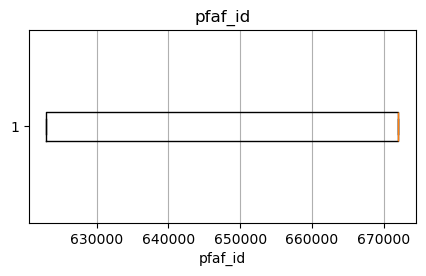

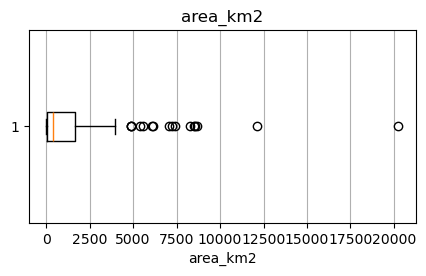

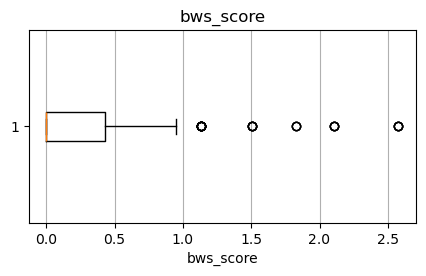

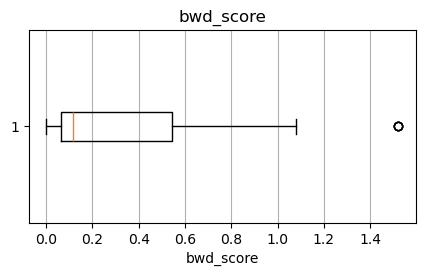

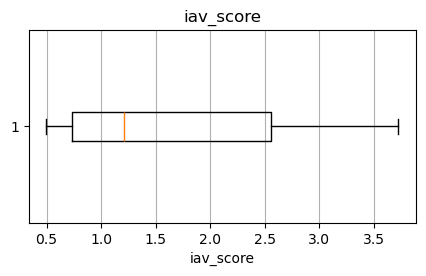

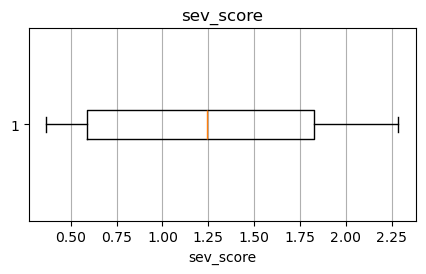

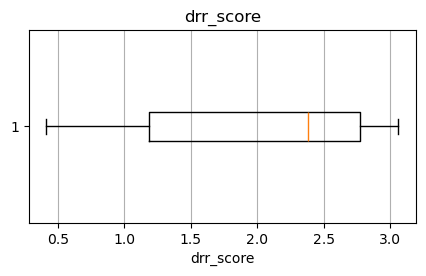

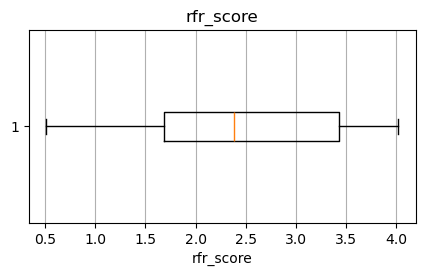

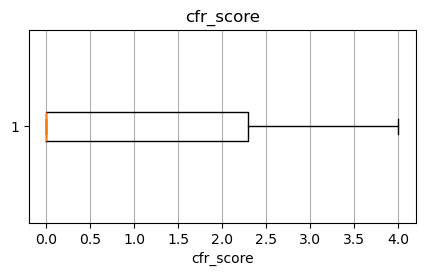

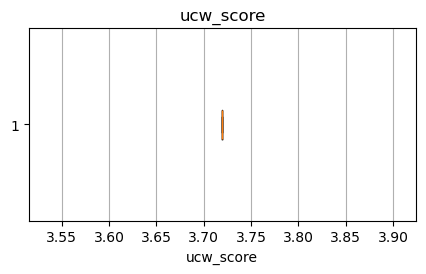

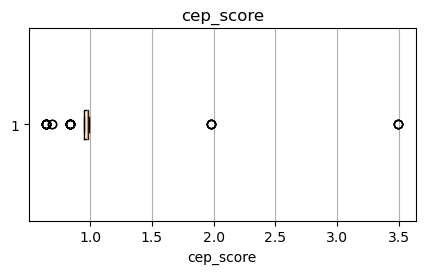

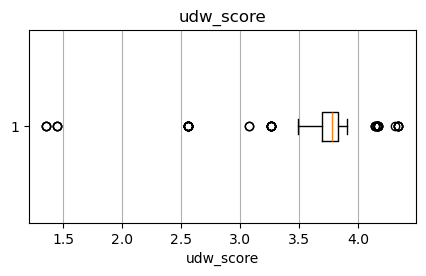

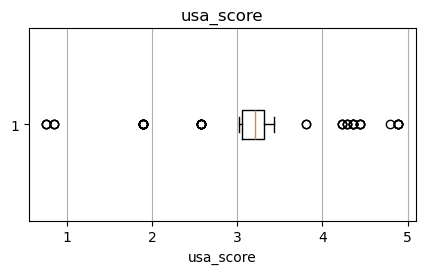

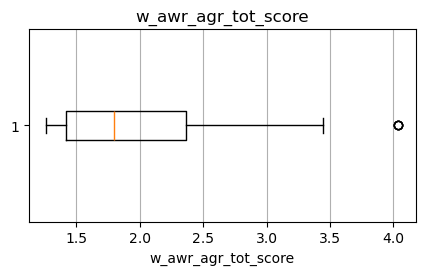

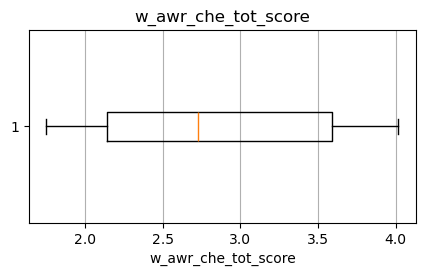

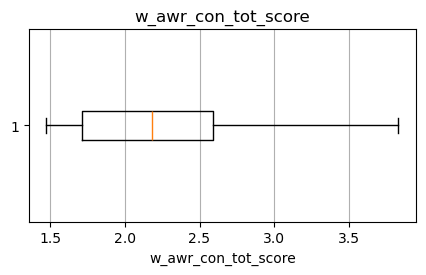

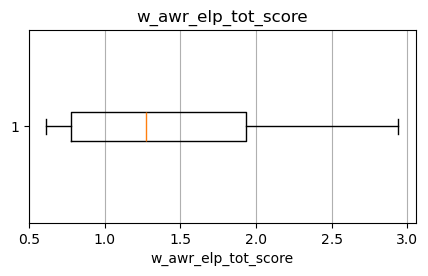

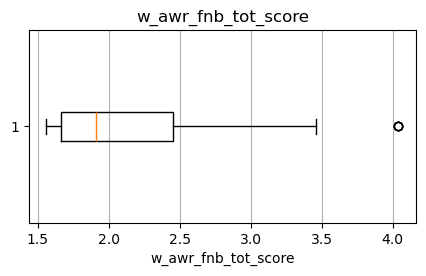

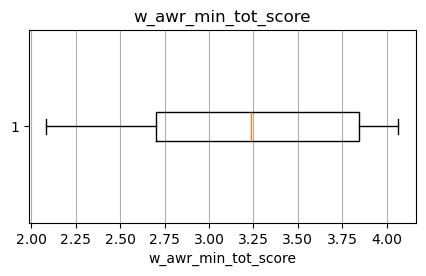

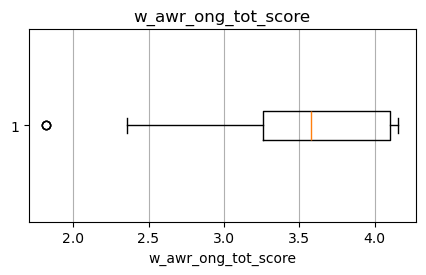

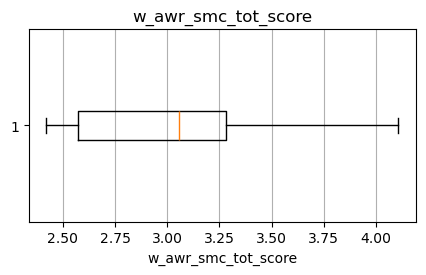

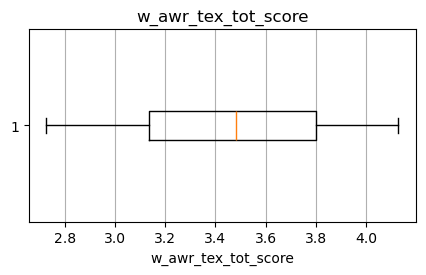

In [42]:
# hacer boxplots de todas las columnas numericas, como subplots y mostrar el nombre de la columna en el titulo del boxplot
numeric_columns = df_selected_ecuador_cleaned.select_dtypes(include=['number']).columns
for col in numeric_columns:
    plt.figure(figsize=(5, 2.5))
    plt.boxplot(df_selected_ecuador_cleaned[col], vert=False)
    plt.grid(axis='x')
    plt.title(f'{col}')
    plt.xlabel(col)
    plt.show()

In [43]:
# agrupar por name 1 y contar por name 1, tambien sumar area_km2, y mostrar el resultado
df_selected_ecuador_cleaned.groupby('name_1').agg({'area_km2': 'sum', 'name_1': 'count'}).rename(columns={'name_1': 'counts'}).sort_values(by='area_km2', ascending=False)

,area_km2,counts
name_1,,
Pastaza,29671.658886,6
Morona Santiago,24097.862502,14
Orellana,21736.893685,2
Manabi,19607.695691,9
Sucumbios,18051.342823,8
Guayas,15886.633771,25
Esmeraldas,15860.052262,6
Napo,12597.874782,9
Loja,11127.777988,8


In [44]:
# exportar dataset limpio a un nuevo csv
df_selected_ecuador_cleaned.to_csv('Aqueduct40_waterrisk_download_Y2023M07D05/CVS/esteEstaLimpioEstresHidricoEcuador.csv', index=False)
if __name__ == "__main__":
    print("Archivo procesado y guardado exitosamente.")

Archivo procesado y guardado exitosamente.


In [45]:
df_selected_ecuador_cleaned['riesgo_hidro'] = df_selected_ecuador_cleaned[riesgo_hidrologico].mean(axis=1)

C:\Users\zevBetaUltra7\AppData\Local\Temp\ipykernel_132656\3555964948.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected_ecuador_cleaned['riesgo_hidro'] = df_selected_ecuador_cleaned[riesgo_hidrologico].mean(axis=1)


In [48]:
df_selected_ecuador_cleaned.groupby('name_1').agg({'area_km2': 'sum', 'riesgo_hidro': 'mean'}).rename(columns={'riesgo_hidro': 'riesgo_hidro_mean'}).sort_values(by='riesgo_hidro_mean', ascending=False)

,area_km2,riesgo_hidro_mean
name_1,,
El Oro,5874.912611,2.028728
Manabi,19607.695691,1.746986
Santa Elena,3717.497458,1.634769
Guayas,15886.633771,1.629778
Loja,11127.777988,1.613748
Los Rios,7315.658808,1.459505
Cañar,3342.517100,1.367430
Azuay,8223.898420,1.327924
Santo Domingo de los Tsachilas,3804.254801,1.251029
